In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

path = "/content/drive/MyDrive/COLLABFILES"
print(os.listdir(path))

['day_wise.csv', 'worldometer_data.csv', 'full_grouped.csv', 'covid_19_clean_complete.csv', 'country_wise_latest.csv', 'usa_county_wise.csv']


In [8]:
import pandas as pd

file_path = "/content/drive/MyDrive/COLLABFILES/covid_19_clean_complete.csv"

df = pd.read_csv(file_path)

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [9]:
df.shape

(49068, 10)

In [10]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [11]:
# Filtering records for Philippines
philippines_data = df[df["Country/Region"] == "Philippines"]

philippines_data.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
180,NaN,Philippines,12.879721,121.774017,2020-01-22,0,0,0,0,Western Pacific
441,NaN,Philippines,12.879721,121.774017,2020-01-23,0,0,0,0,Western Pacific
702,NaN,Philippines,12.879721,121.774017,2020-01-24,0,0,0,0,Western Pacific
963,NaN,Philippines,12.879721,121.774017,2020-01-25,0,0,0,0,Western Pacific
1224,NaN,Philippines,12.879721,121.774017,2020-01-26,0,0,0,0,Western Pacific


In [12]:
# Aggregation: total confirmed cases
total_confirmed = df["Confirmed"].sum()

print("Total Confirmed Cases:", total_confirmed)

Total Confirmed Cases: 828508482


In [13]:
# Sorting by highest confirmed cases
sorted_cases = df.sort_values(by="Confirmed", ascending=False)

sorted_cases.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49030,NaN,US,40.0,-100.0,2020-07-27,4290259,148011,1325804,2816444,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
47725,NaN,US,40.0,-100.0,2020-07-22,3970121,143316,1210849,2615956,Americas
47464,NaN,US,40.0,-100.0,2020-07-21,3899211,142121,1182018,2575072,Americas
47203,NaN,US,40.0,-100.0,2020-07-20,3834677,141025,1160087,2533565,Americas
46942,NaN,US,40.0,-100.0,2020-07-19,3773260,140534,1131121,2501605,Americas
46681,NaN,US,40.0,-100.0,2020-07-18,3711413,140119,1122720,2448574,Americas


In [14]:
import time

start_time = time.time()

# Filtering
philippines_data = df[df["Country/Region"] == "Philippines"]

# Aggregation
total_confirmed = df["Confirmed"].sum()

# Sorting
sorted_cases = df.sort_values(by="Confirmed", ascending=False)

end_time = time.time()

sequential_time = end_time - start_time

print("Sequential Execution Time:", sequential_time)

Sequential Execution Time: 0.027570486068725586


The Total Sequential Execution Time is:
###0.027570486068725586

In [17]:
import multiprocessing as mp
import time

def filter_data():
    return df[df["Country/Region"] == "Philippines"]

def aggregate_data():
    return df["Confirmed"].sum()

def sort_data():
    return df.sort_values(by="Confirmed", ascending=False)

def run_task(task):
    if task == 1:
        return filter_data()
    elif task == 2:
        return aggregate_data()
    elif task == 3:
        return sort_data()

start_time = time.time()

with mp.Pool(processes=3) as pool:
    results = pool.map(run_task, [1,2,3])

end_time = time.time()

parallel_time = end_time - start_time

print("Parallel Execution Time:", parallel_time)

Parallel Execution Time: 0.12957000732421875


The Total Parallel Execution Time:
###0.12957000732421875

In [18]:
import pandas as pd

performance_table = pd.DataFrame({
    "Method": ["Sequential", "Parallel"],
    "Execution Time (seconds)": [sequential_time, parallel_time]
})

performance_table

,Method,Execution Time (seconds)
0,Sequential,0.02757
1,Parallel,0.12957


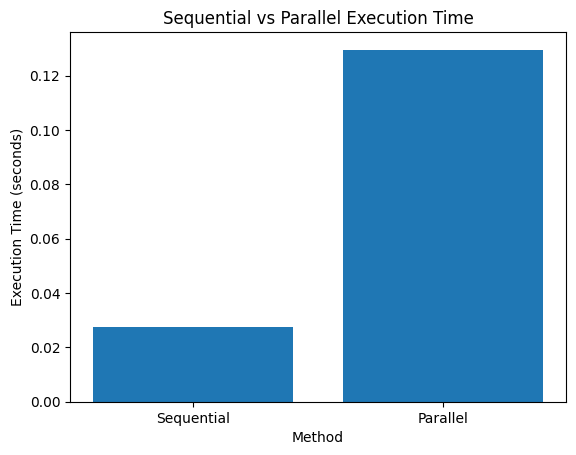

In [19]:
import matplotlib.pyplot as plt

methods = ["Sequential", "Parallel"]
times = [sequential_time, parallel_time]

plt.bar(methods, times)
plt.title("Sequential vs Parallel Execution Time")
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Method")
plt.show()